# Notebook to perform EDA of CosMX RNA Data

# TODO
- How to handle genes that are not present in refProfiles?

## Instructions

- 

## Imports

In [1]:
# Load Packages
library(Seurat)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)
library(InSituCor)
library(pheatmap)
library(grid)
library(ComplexHeatmap)
library(viridis)
library(circlize)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: Rcpp

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published rese

In [2]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [3]:
# Define directories
seu_file_path <- file.path("../outputs/TMA18/seurat_objects/annotated_object_TMA18_louvain_final.RDS")
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "InsituCor")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

Define Parameters

In [4]:
ASSAY_NAME <- "RNA"
sdimx_col <- "x_slide_mm"
sdimy_col <- "y_slide_mm"
study_id_col <- "study_id"
region_col <- "region"
annotation_col <- "final_annotation"
# annotation_col <- "broad_annotation"

# Subset
subset <- FALSE

Loading Seurat object

In [5]:
# Load Seurat object
seu <- readRDS(seu_file_path)

In [6]:
# colnames(seu@meta.data)
head(seu@meta.data, n=5)

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,Hypoxia,JAK.STAT,MAPK,NFkB,p53,PI3K,TGFb,TNFa,VEGF,WNT
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,0.02764038,0.05942612,0.04055166,0.03884804,0.031511387,0.04290894,0.06802008,0.03073901,0.046658544,0.01558131
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,0.03139042,0.04145884,0.03591060,0.02818627,0.020165631,0.01697220,0.06331808,0.02367287,0.059203105,0.04152923
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,0.02347008,0.04781443,0.04479774,0.04083333,0.021656315,0.01198630,0.02478079,0.03604500,0.034881097,0.01715201
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,0.03569004,0.03110754,0.03186202,0.05433824,0.049896480,0.04044118,0.09044987,0.04543251,0.017869230,0.03311029
18_c_1_100_171,100,6681,0.94,1935,1398,89,95,11505.6,34672,237.2,⋯,0.05738208,0.03309198,0.06938547,0.02370098,0.005755694,0.01475624,0.02109544,0.03336650,0.008302874,0.02129865


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


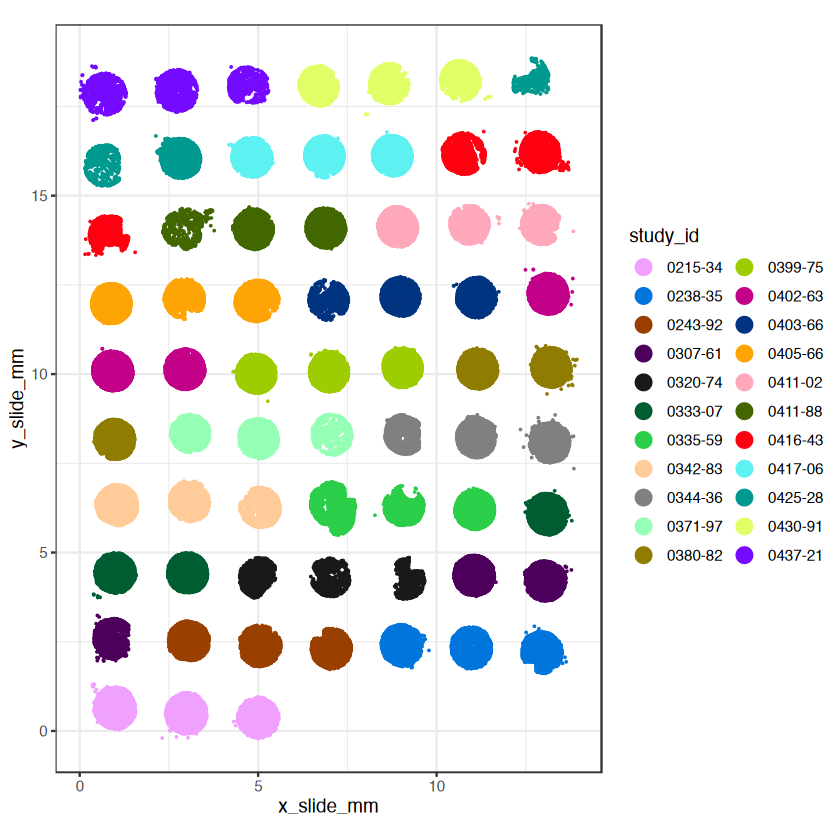

In [7]:
# Visualize the data
xyplot(study_id_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [8]:
unique(seu@meta.data[[study_id_col]])
unique(seu@meta.data[[region_col]])

[1] "0411-88" "0405-66" "0402-63" "0425-28" "0371-97" "0342-83" "0333-07"
 [8] "0243-92" "0215-34" "0437-21" "0416-43" "0417-06" "0399-75" "0320-74"
[15] "0430-91" "0403-66" "0335-59" "0411-02" "0344-36" "0238-35" "0380-82"
[22] "0307-61"

[1] 18_F8  18_F7  18_F6  18_G9  18_F5  18_F4  18_F3  18_F2  18_F1  18_E10
[11] 18_G8  18_E9  18_E8  18_E7  18_E6  18_E5  18_G10 18_E4  18_E3  18_E2 
[21] 18_E1  18_D10 18_D9  18_G7  18_D8  18_D7  18_D6  18_D5  18_D4  18_D3 
[31] 18_D2  18_C10 18_C9  18_C8  18_G6  18_C7  18_C6  18_C5  18_C4  18_C3 
[41] 18_C2  18_B10 18_B9  18_B8  18_B7  18_G5  18_B6  18_B5  18_B4  18_B3 
[51] 18_B2  18_A10 18_A9  18_A8  18_A7  18_A6  18_A5  18_G4  18_A4  18_A3 
[61] 18_A2  18_G3  18_G2  18_G1  18_F10 18_F9 
66 Levels: 18_A2 18_A3 18_A4 18_A5 18_A6 18_A7 18_A8 18_A9 18_A10 ... 18_G10

Setting

In [9]:
if (subset) {

    # Filter for one patient only
    seu <- subset(seu, subset = study_id %in% c("0238-35"))

    # Filter for one region only
    # seu <- subset(seu, subset = region %in% c("18_C9"))

}

# Drop unused levels
seu@meta.data[[region_col]] <- droplevels(seu@meta.data[[region_col]])

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


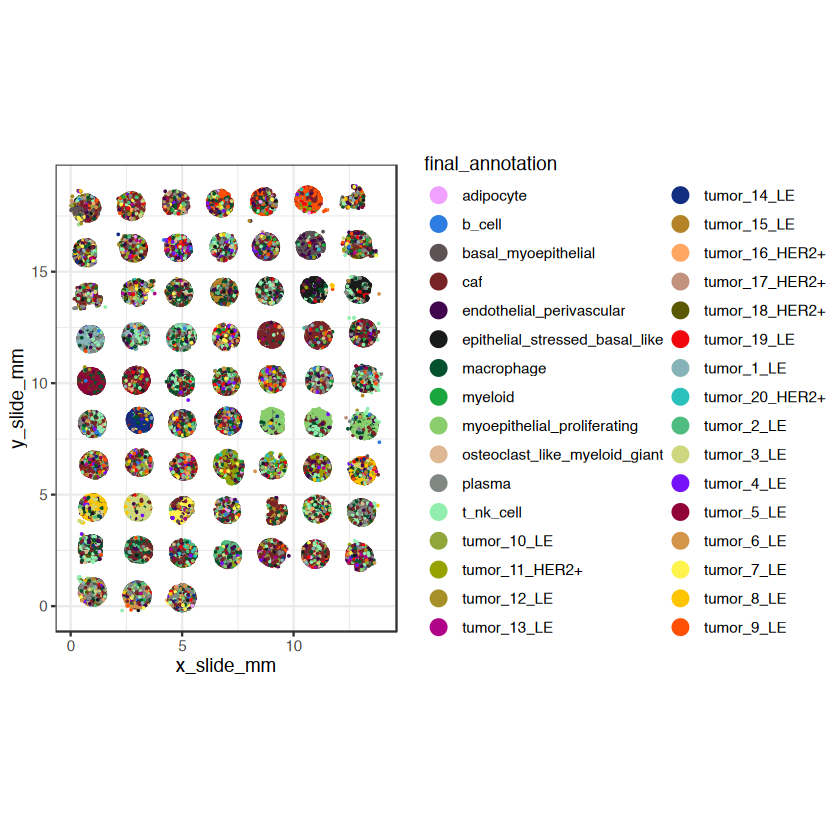

In [10]:
# Visualize the data
xyplot(annotation_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [11]:
nrow(seu)
ncol(seu)

[1] 6175

[1] 189704

Prepare the data

In [12]:
# Counts Data
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)
neg_counts <- Matrix::t(seu[["negprobes"]]$counts)
metadata <- seu@meta.data # row-aligned with the counts matrix
metadata$neg_total_counts <- Matrix::rowSums(neg_counts)
metadata$negmean <- Matrix::rowMeans(neg_counts)
xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])

# Quick check: are the cell IDs of 'counts', 'metadata', and 'xy' in the same order?
all(rownames(counts) == rownames(metadata))
all(rownames(counts) == rownames(xy))

## normalize counts matrix using efficient sparse matrix calls:
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

[1] TRUE

[1] TRUE

## Single Tissue

In [13]:
# Parameters
tissue <- metadata[[region_col]]
k <- 50
min_module_size <- 3
min_module_cor <- 0.25
max_module_size <- 20
weighting <- "inverse_sqrt"
attribution_subset_size <- 5000

In [14]:
conditionon_cols <- c("fov", "nCount_RNA", "negmean", annotation_col)
conditionon_cols

[1] "fov"              "nCount_RNA"       "negmean"          "final_annotation"

In [15]:
conditionon <- as.data.frame(metadata[, conditionon_cols, drop = FALSE])

In [ ]:
# Run InsituCor
res <- InSituCor::insitucor(
         # fundamental input data:
         counts = norm, 
         conditionon = conditionon, 
         celltype = metadata[[annotation_col]],
         # args for neighbor definition:
         neighbors = NULL, xy = xy, k = k, radius = NULL, tissue = tissue,  
         # args for module definition:
         min_module_size = min_module_size, max_module_size = max_module_size, min_module_cor = min_module_cor,
         gene_weighting_rule = weighting,   
         # args for controlling memory and compute
         roundcortozero = 0.1, max_cells = 100000,                               
         # args for cell type attribution scoring
         attribution_subset_size = attribution_subset_size,                                      
         verbose = FALSE)
str(res)

[1] "building nearest neighbors network"
[1] "building environment expression matrix"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.6 GiB”
Warning message in dataframe_neighborhood_summary(df = conditionon, neighbors = neighbors[use, :
“Character variable fov has over 200 unique values. It is actually a numeric variable?”


[1] 260   3

module,gene,weight
<chr>,<chr>,<dbl>
CFP_RHOF_33,AAK1,0.03115063
CFP_RHOF_33,ACACA,0.01979236
CFP_RHOF_33,AKT3,0.03173659
CFP_RHOF_33,CAMK1,0.02939725
CFP_RHOF_33,CAMK2B,0.03720515
CFP_RHOF_33,CFP,0.03297894


[1] 27

[1] 7441   27

,CFP_RHOF_33,ACBD6_ENDOD1_29,RSPO3_LPAR2_24,TUBB4B_VTN_16,SLC39A6_ISG15_16,CCL13_CCNA2_15,PSMC1_SUN2_14,PKMYT1_SETBP1_14,FST_POLR2H_12,GAP43_JAG2_11,⋯,LDB2_EPHA2_4,IL2RA_KPNA3_RRAGA_3,CCRL2_SOX2_ADCY3_3,ISG20_LEPROT_RUBCN_3,DDB1_EPN2_SP1_3,ELL_GAS2_EPO_3,DKK2_TOMM70_VEGFD_3,NRAS_RUSC2_PPP1R15B_3,BHLHE40_HLA.DQA2_FLNB_3,PDE3A_FUS_RAET1G_3
18_c_1_361_100,0.02574035,0.04995897,0.03815637,0.15218740,0.5246300,0.10428281,0.06238987,0.01972404,0.02210581,0.08702027,⋯,0.00000000,0.16148717,0.00000000,0.0000000,0.26027894,0.18906364,0.0000000,0.00000000,0.09365054,0.08673024
18_c_1_361_102,0.00000000,0.00000000,0.32375934,0.00000000,0.1487012,0.00000000,0.00000000,0.53485899,0.14579550,0.00000000,⋯,0.00000000,0.00000000,0.00000000,1.5849575,0.00000000,0.00000000,0.0000000,0.00000000,0.00000000,0.48126274
18_c_1_361_12,0.03831893,0.10855316,0.03398242,0.12954189,1.2307114,0.12854788,0.05872258,0.09736402,0.09938385,0.12184648,⋯,0.10662574,0.06855414,0.06267896,0.1239402,0.05953587,0.06265138,0.0000000,0.06162039,0.26588409,0.00000000
18_c_1_361_120,0.04304586,0.11546623,0.04723723,0.02792934,0.5436586,0.09581718,0.28821179,0.07350567,0.05385175,0.00000000,⋯,0.08230776,0.00000000,0.00000000,0.1624871,0.00000000,0.00000000,0.4905129,0.00000000,0.19301679,0.00000000
18_c_1_361_125,0.05311829,0.10782875,0.12895686,0.00000000,0.3670160,0.00000000,0.00000000,0.14739580,0.00000000,0.00000000,⋯,0.00000000,0.00000000,0.00000000,0.5652726,0.00000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000
18_c_1_361_126,0.12402379,0.08895586,0.12834827,0.14862414,0.3265923,0.07276760,0.00000000,0.08764922,0.00000000,0.12875590,⋯,0.00000000,0.00000000,0.00000000,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,0.00000000,0.00000000


[1] 7441   27

,CFP_RHOF_33,ACBD6_ENDOD1_29,RSPO3_LPAR2_24,TUBB4B_VTN_16,SLC39A6_ISG15_16,CCL13_CCNA2_15,PSMC1_SUN2_14,PKMYT1_SETBP1_14,FST_POLR2H_12,GAP43_JAG2_11,⋯,LDB2_EPHA2_4,IL2RA_KPNA3_RRAGA_3,CCRL2_SOX2_ADCY3_3,ISG20_LEPROT_RUBCN_3,DDB1_EPN2_SP1_3,ELL_GAS2_EPO_3,DKK2_TOMM70_VEGFD_3,NRAS_RUSC2_PPP1R15B_3,BHLHE40_HLA.DQA2_FLNB_3,PDE3A_FUS_RAET1G_3
18_c_1_361_100,0.07732839,0.08356188,0.07561669,0.11301077,0.5068641,0.09039154,0.05350664,0.06847948,0.05717436,0.11954258,⋯,0.06202779,0.05188653,0.01194743,0.05525271,0.10553634,0.12688350,0.08050601,0.09823051,0.22790866,0.02318822
18_c_1_361_102,0.06619063,0.10290615,0.09235576,0.11419477,0.5232398,0.13554909,0.08164351,0.13847353,0.08264087,0.07425950,⋯,0.06152745,0.05507914,0.01904369,0.04198785,0.10280173,0.18541889,0.07730725,0.04871837,0.24875385,0.01957377
18_c_1_361_12,0.08070654,0.07911760,0.06972413,0.08890757,0.5926978,0.12879774,0.05823896,0.11285502,0.05056076,0.04942883,⋯,0.06207744,0.06218336,0.07039956,0.15315973,0.04093261,0.08478208,0.09868197,0.10162629,0.08964678,0.06773505
18_c_1_361_120,0.06324473,0.08126820,0.10165863,0.10884628,0.4308618,0.10066895,0.07133049,0.07090880,0.06471876,0.09241972,⋯,0.02048976,0.06203518,0.02849920,0.07858519,0.13866533,0.26156337,0.09611278,0.10948829,0.29697273,0.02525830
18_c_1_361_125,0.07546921,0.07761662,0.07139802,0.11737198,0.4810564,0.08408579,0.08112826,0.08083601,0.06476762,0.11451534,⋯,0.05726952,0.05511627,0.01379809,0.06404999,0.10371852,0.12726363,0.07859440,0.07674604,0.26143797,0.02908424
18_c_1_361_126,0.09009199,0.08174015,0.06125895,0.11798267,0.4807150,0.08674491,0.05690470,0.08433917,0.05615212,0.12520356,⋯,0.07499090,0.05377624,0.01379809,0.07440021,0.08893602,0.13822238,0.11754332,0.08845734,0.22328591,0.05122207


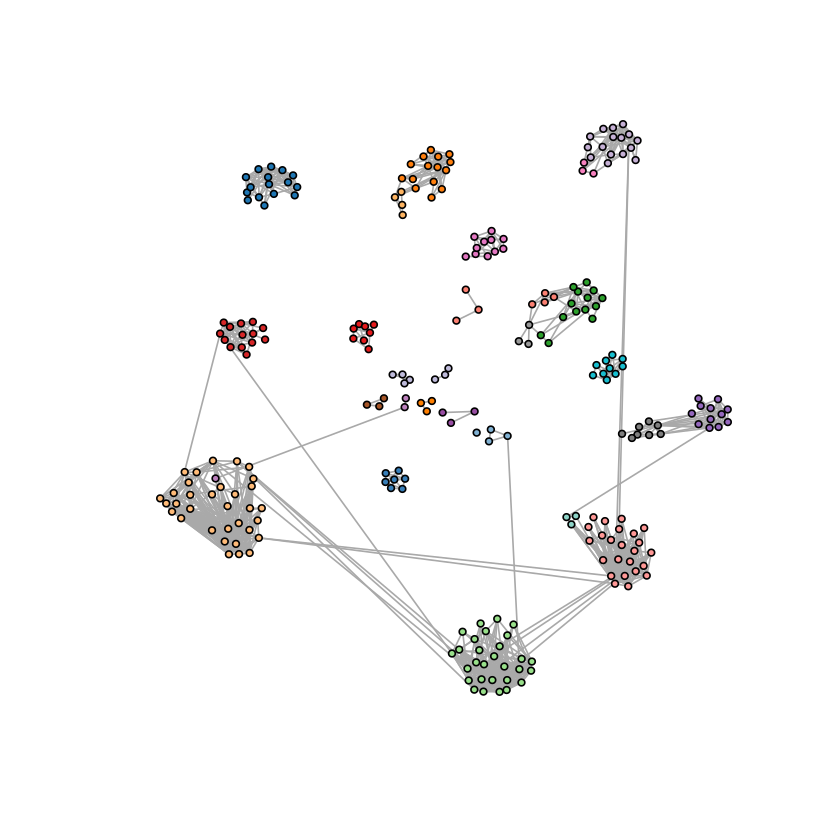

In [ ]:
# Modules
dim(res$modules)
head(res$modules)

length(unique(res$modules$module))

# SC scores
dim(res$scores_sc)
head(res$scores_sc)

# ENV scores
dim(res$scores_env)
head(res$scores_env)

# look at the spatial correlation network:
plotCorrelationNetwork(res$condcor, modules = res$modules, show_gene_names = FALSE, 
                       corthresh = 0.25)

In [ ]:
output_file <- file.path(full_out_dir, paste0("InsituCor_Modules_ST_", study_name, 
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_k", k,
  "minMC", min_module_cor,
  "_wts", weighting,
  ".csv"
))

write.csv(res$modules, output_file, row.names = FALSE)

In [ ]:
# Result Summary
output_file <- file.path(full_out_dir, paste0("InsituCor_Results_ST_", study_name, 
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_k", k,
  "minMC", min_module_cor,
  "_wts", weighting,
  ".pdf"
))
summarize_insitucor(res, corthresh = 0.25, output_file = output_file)

✓ Summary report created successfully: ../outputs/TMA18/InsituCor/InsituCor_Results_ST_TMA18_minMS3_maxMS20_k50minMC0.25_wtsinverse_sqrt.pdf 
✓ File size: 61.58 KB


In [ ]:
# Per Module Result Summary
output_file <- file.path(full_out_dir, paste0("InsituCor_Results_ST_perModule_", study_name, 
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_k", k,
  "minMC", min_module_cor,
  "_wts", weighting,
  ".pdf"
))

plot_module_details(res, xy, output_file = output_file)

Processing module 1 of 27 : CFP_RHOF_33 
Processing module 2 of 27 : ACBD6_ENDOD1_29 
Processing module 3 of 27 : RSPO3_LPAR2_24 
Processing module 4 of 27 : TUBB4B_VTN_16 
Processing module 5 of 27 : SLC39A6_ISG15_16 
Processing module 6 of 27 : CCL13_CCNA2_15 
Processing module 7 of 27 : PSMC1_SUN2_14 
Processing module 8 of 27 : PKMYT1_SETBP1_14 
Processing module 9 of 27 : FST_POLR2H_12 
Processing module 10 of 27 : GAP43_JAG2_11 
Processing module 11 of 27 : NPEPPS_CCNT1_10 
Processing module 12 of 27 : GRID1_HGS_8 
Processing module 13 of 27 : NLRP2_CDH5_8 
Processing module 14 of 27 : CCDC88A_CMA1_7 
Processing module 15 of 27 : APCDD1_ZBTB16_4 
Processing module 16 of 27 : AP4B1_PRC1_4 
Processing module 17 of 27 : ZNF536_GRIA3_4 
Processing module 18 of 27 : LDB2_EPHA2_4 
Processing module 19 of 27 : IL2RA_KPNA3_RRAGA_3 
Processing module 20 of 27 : CCRL2_SOX2_ADCY3_3 
Processing module 21 of 27 : ISG20_LEPROT_RUBCN_3 
Processing module 22 of 27 : DDB1_EPN2_SP1_3 
Processing m

In [ ]:
# Module Correlations
output_file <- file.path(full_out_dir, paste0("InsituCor_Results_ST_CorrsperModule_", study_name, 
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_k", k,
  "minMC", min_module_cor,
  "_wts", weighting,
  ".pdf"
))

stats <- analyze_module_correlations(res, output_file = output_file)
head(stats)  # See the calculated statistics

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'



✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_ST_CorrsperModule_TMA18_minMS3_maxMS20_k50minMC0.25_wtsinverse_sqrt.pdf 


,module,n_genes,mean_cor
,<fct>,<int>,<dbl>
CFP_RHOF_33,CFP_RHOF_33,33,0.2502434
ACBD6_ENDOD1_29,ACBD6_ENDOD1_29,29,0.2575904
RSPO3_LPAR2_24,RSPO3_LPAR2_24,24,0.2719978
SLC39A6_ISG15_16,SLC39A6_ISG15_16,16,0.2811950
TUBB4B_VTN_16,TUBB4B_VTN_16,16,0.2558700
CCL13_CCNA2_15,CCL13_CCNA2_15,15,0.2518543


## Multi Sample

In [14]:
conditionon_cols <- c("fov", "nCount_RNA", "negmean", annotation_col)
conditionon_cols

[1] "fov"              "nCount_RNA"       "negmean"          "final_annotation"

In [15]:
# Analysis level: "core" or "patient"
analysis_level <- "patient"

if (analysis_level == "core") {
    unit_col <- region_col
    tissue_col <- NULL                    # single core = no cross-tissue issue
    relevant_units <- unique(metadata[[region_col]])
} else if (analysis_level == "patient") {
    unit_col <- study_id_col
    tissue_col <- region_col              # prevent cross-core neighbors within a patient
    relevant_units <- unique(metadata[[study_id_col]])
}

cat("Analysis level:", analysis_level, "\n")
cat("Grouping by:", unit_col, "(", length(relevant_units), "units)\n")
if (!is.null(tissue_col)) cat("Tissue column:", tissue_col, "\n")

Analysis level: patient 
Grouping by: study_id ( 22 units)
Tissue column: region 


In [16]:
# Cell counts per unit
cat("\nCells per unit:\n")
unit_counts <- table(metadata[[unit_col]][metadata[[unit_col]] %in% relevant_units])
print(unit_counts)

# Identify units to remove (< N cells as threshold)
min_cells_per_unit <- 2000
cat(paste0("\nRemoving units with < ", min_cells_per_unit, " cells\n"))
low_count_units <- names(unit_counts)[unit_counts < min_cells_per_unit]
if (length(low_count_units) > 0) {
  cat("WARNING: These units have too few cells and will be skipped:\n")
  print(low_count_units)
} else {
  cat("No units will be skipped\n")
}


Cells per unit:

0215-34 0238-35 0243-92 0307-61 0320-74 0333-07 0335-59 0342-83 0344-36 0371-97 
   9492    7441   11058   11444    8100   13158    6793    6384    7619    5391 
0380-82 0399-75 0402-63 0403-66 0405-66 0411-02 0411-88 0416-43 0417-06 0425-28 
  11933   11361    9234    4746   15119    7370    6498    6338   13487    5698 
0430-91 0437-21 
   5856    5184 

Removing units with < 2000 cells
No units will be skipped


In [17]:
prepared_data <- prepare_insitucor_data(
    counts, norm, metadata, xy,
    units = relevant_units,
    unit_col = unit_col,
    tissue_col = tissue_col,
    min_cells_per_unit = min_cells_per_unit
)

Preparing data for 22 units (grouped by study_id )...
   0411-88 : 6498 cells
   0405-66 : 15119 cells
   0402-63 : 9234 cells
   0425-28 : 5698 cells
   0371-97 : 5391 cells
   0342-83 : 6384 cells
   0333-07 : 13158 cells
   0243-92 : 11058 cells
   0215-34 : 9492 cells
   0437-21 : 5184 cells
   0416-43 : 6338 cells
   0417-06 : 13487 cells
   0399-75 : 11361 cells
   0320-74 : 8100 cells
   0430-91 : 5856 cells
   0403-66 : 4746 cells
   0335-59 : 6793 cells
   0411-02 : 7370 cells
   0344-36 : 7619 cells
   0238-35 : 7441 cells
   0380-82 : 11933 cells
   0307-61 : 11444 cells


In [18]:
min_module_size <- 3
min_module_cor <- 0.25
k <- 50
corthresh <- 0.25 # for network plotting

results <- run_insitucor_multiple_units(
    prepared_data, 
    run_insitucor_single_unit, 
    conditionon_cols = conditionon_cols, 
    k = k, 
    annotation_col = annotation_col, 
    min_module_size = min_module_size,
    min_module_cor = min_module_cor,
    output_dir = full_out_dir,
    study_name = study_name,
    verbose = FALSE
)


Running InsituCor sequentially on 22 units...

=== Running InsituCor on unit: 0411-88 ===
Cells: 6498 
Using tissue column: region ( 3 unique values)
[1] "building nearest neighbors network"
[1] "building environment expression matrix"
[1] "building confounder matrix"
[1] "calculating conditional correlation"
Saved results to: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_TMA18_unit0411-88_minModuleSize3_minModuleCor0.25_k50.rds 

=== Running InsituCor on unit: 0405-66 ===
Cells: 15119 
Using tissue column: region ( 3 unique values)
[1] "building nearest neighbors network"
[1] "building environment expression matrix"
[1] "building confounder matrix"
[1] "calculating conditional correlation"
Saved results to: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_TMA18_unit0405-66_minModuleSize3_minModuleCor0.25_k50.rds 

=== Running InsituCor on unit: 0402-63 ===
Cells: 9234 
Using tissue column: region ( 3 unique values)
[1] "building nearest 

In [19]:
# Print summary plots
for (unit_name in names(results)) {

  print(paste0("Processing unit: ", unit_name))
  
  res <- results[[unit_name]]
  xy_unit <- xy[metadata[[unit_col]] == unit_name, ]
  
  # Summary Plot
  output_file <- file.path(
    full_out_dir, "InsituCor_Results_perUnit",
    paste0("InsituCor_Results_",
           unit_name, "_",
           study_name, "_",
           "minModuleSize", min_module_size, 
           "_minModuleCor", min_module_cor, 
           ".pdf")
  )
  summarize_insitucor(res, corthresh = corthresh, output_file = output_file)

  # Module Correlations
  output_file <- file.path(
    full_out_dir, "InsituCor_Results_perUnit",
    paste0("InsituCor_Results_perModule_Correlations_",
           unit_name, "_",
           study_name, "_",
           "minModuleSize", min_module_size, 
           "_minModuleCor", min_module_cor, 
           ".pdf")
  )
  analyze_module_correlations(res, output_file = output_file)

  # Module Details
  output_file <- file.path(
    full_out_dir, "InsituCor_Results_perUnit",
    paste0("InsituCor_Results_perModule_",
           unit_name, "_",
           study_name, "_",
           "minModuleSize", min_module_size, 
           "_minModuleCor", min_module_cor, 
           ".pdf")
  )
  plot_module_details(res, xy_unit, output_file = output_file)
}

[1] "Processing unit: 0411-88"
✓ Summary report created successfully: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_0411-88_TMA18_minModuleSize3_minModuleCor0.25.pdf 
✓ File size: 264.34 KB


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'



✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_Correlations_0411-88_TMA18_minModuleSize3_minModuleCor0.25.pdf 
Processing module 1 of 88 : MIR4435.2HG_ATP6V1D_68 
Processing module 2 of 88 : FLT1_OSBPL3_63 
Processing module 3 of 88 : SELENOS_IL17B_48 
Processing module 4 of 88 : TSPAN7_TAF4_33 
Processing module 5 of 88 : ADGRA3_ARC_30 
Processing module 6 of 88 : PLCB4_RORC_29 
Processing module 7 of 88 : PSAP_CTSD_29 
Processing module 8 of 88 : POLR3K_NRAS_28 
Processing module 9 of 88 : IFT88_KCNJ11_27 
Processing module 10 of 88 : SNRPN_NTRK2_26 
Processing module 11 of 88 : HSD17B12_SELENBP1_24 
Processing module 12 of 88 : PDHB_PRKAR2A_23 
Processing module 13 of 88 : WNT7B_SLC23A2_23 
Processing module 14 of 88 : PREP_ARTN_20 
Processing module 15 of 88 : ANKRD22_ADGRG5_20 
Processing module 16 of 88 : DNM1_GLTP_19 
Processing module 17 of 88 : CDK11A_STT3B_19 
Processing module 18 of 88 : STMN2_USP7_19 
Processing module 19 of 88 

`geom_smooth()` using formula = 'y ~ x'



✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_Correlations_0405-66_TMA18_minModuleSize3_minModuleCor0.25.pdf 
Processing module 1 of 27 : NUDT1_MRC1_36 
Processing module 2 of 27 : GDF15_HMOX1_30 
Processing module 3 of 27 : SRD5A1_RNF185_30 
Processing module 4 of 27 : KRT19_ALDOA_25 
Processing module 5 of 27 : COL3A1_COL1A2_24 
Processing module 6 of 27 : C1QC_C1QB_23 
Processing module 7 of 27 : CAMP_SSTR1_23 
Processing module 8 of 27 : PSMA8_NUP153_20 
Processing module 9 of 27 : UFD1_BAG3_19 
Processing module 10 of 27 : SALL3_INVS_19 
Processing module 11 of 27 : GBP4_GBP1_19 
Processing module 12 of 27 : ERAP2_FGF19_18 
Processing module 13 of 27 : CAMK2B_HTR6_18 
Processing module 14 of 27 : CDH19_FZD3_17 
Processing module 15 of 27 : CPNE8_PDYN_16 
Processing module 16 of 27 : SLC6A11_DLL4_16 
Processing module 17 of 27 : ISG15_MX1_15 
Processing module 18 of 27 : IGLL1_IGLL5_14 
Processing module 19 of 27 : LIN52_SLC16A1_12 
Pr

...


✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_Correlations_0238-35_TMA18_minModuleSize3_minModuleCor0.25.pdf 
Processing module 1 of 13 : CFP_RHOF_33 
Processing module 2 of 13 : ACBD6_ENDOD1_29 
Processing module 3 of 13 : RSPO3_LPAR2_24 
Processing module 4 of 13 : ENDOG_ZC3H12A_19 
Processing module 5 of 13 : SEC24B_YEATS2_11 
Processing module 6 of 13 : CCNT1_NPEPPS_11 
Processing module 7 of 13 : IL1B_APBB1IP_4 
Processing module 8 of 13 : TAF3_HSPBP1_4 
Processing module 9 of 13 : NFKBIB_JAK2_PCLO_3 
Processing module 10 of 13 : P3H2_PDE4D_GPX2_3 
Processing module 11 of 13 : COL4A3_ZP3_THEM4_3 
Processing module 12 of 13 : WAPL_VANGL2_GPR151_3 
Processing module 13 of 13 : NRAS_RUSC2_PPP1R15B_3 

✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_0238-35_TMA18_minModuleSize3_minModuleCor0.25.pdf 
✓ Pages: 53 
[1] "Processing unit: 0380-82"
✓ Summary report created successfully: ../outputs/TMA

`geom_smooth()` using formula = 'y ~ x'



✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_Correlations_0380-82_TMA18_minModuleSize3_minModuleCor0.25.pdf 
Processing module 1 of 24 : GNPAT_LAMTOR2_29 
Processing module 2 of 24 : APBA1_PCSK9_26 
Processing module 3 of 24 : CACNA2D3_PLPP1_24 
Processing module 4 of 24 : SVIP_NPR2_23 
Processing module 5 of 24 : DLL1_PHEX_21 
Processing module 6 of 24 : COL1A1_COL1A2_18 
Processing module 7 of 24 : PPBP_NSUN3_18 
Processing module 8 of 24 : OPHN1_LGR4_18 
Processing module 9 of 24 : ELP6_PLEKHA1_17 
Processing module 10 of 24 : ASPA_HERC6_15 
Processing module 11 of 24 : CENPM_ETS1_14 
Processing module 12 of 24 : FGF8_DNAH7_11 
Processing module 13 of 24 : AQP7_PHKA1_11 
Processing module 14 of 24 : CD74_HLA.DRB_11 
Processing module 15 of 24 : COL9A2_DLG1_9 
Processing module 16 of 24 : ENDOD1_MCRS1_9 
Processing module 17 of 24 : TGS1_THRB_7 
Processing module 18 of 24 : SCGB2A2_AGR2_6 
Processing module 19 of 24 : NDUFB3_TRIM9_6 
Pr

`geom_smooth()` using formula = 'y ~ x'



✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_perUnit/InsituCor_Results_perModule_Correlations_0307-61_TMA18_minModuleSize3_minModuleCor0.25.pdf 
Processing module 1 of 41 : CADM4_HOXA11_41 
Processing module 2 of 41 : LTK_NAV3_39 
Processing module 3 of 41 : FPR1_LRRK2_34 
Processing module 4 of 41 : NUDT15_AAAS_31 
Processing module 5 of 41 : BCAN_LANCL1_30 
Processing module 6 of 41 : COL1A1_COL1A2_29 
Processing module 7 of 41 : CFB_S100A9_28 
Processing module 8 of 41 : FLNA_TACSTD2_28 
Processing module 9 of 41 : SMUG1_SNTB1_25 
Processing module 10 of 41 : FUNDC1_NKX2.2_24 
Processing module 11 of 41 : MYH11_TM4SF1_23 
Processing module 12 of 41 : MX1_ISG15_21 
Processing module 13 of 41 : TNXA.B_COPS8_20 
Processing module 14 of 41 : DMBT1_NEK9_20 
Processing module 15 of 41 : OLIG2_P2RY10_20 
Processing module 16 of 41 : HSD17B2_IRAK3_19 
Processing module 17 of 41 : PPP1R1B_FADS2_19 
Processing module 18 of 41 : NLGN4X_RAP1GAP_18 
Processing module 19 of 41 : RAB22

### Consensus Analysis

In [30]:
# Load helper functions
source("helper_functions.R")

In [21]:
results_dir <- file.path(full_out_dir, "InsituCor_Results_perUnit")
inspect_results_directory(results_dir)

Found 22 RDS files

Files found: InsituCor_Results_TMA18_unit0215-34_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0238-35_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0243-92_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0307-61_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0320-74_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0333-07_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0335-59_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0342-83_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0344-36_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0371-97_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0380-82_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0399-75_minModuleSize3_minModuleCor0.25_k50.rds, InsituCor_Results_TMA18_unit0402-63_minModu

file,size_mb,modified
<chr>,<dbl>,<dttm>
InsituCor_Results_TMA18_unit0215-34_minModuleSize3_minModuleCor0.25_k50.rds,9.072267,2026-02-20 13:26:09
InsituCor_Results_TMA18_unit0238-35_minModuleSize3_minModuleCor0.25_k50.rds,8.405848,2026-02-20 14:33:31
InsituCor_Results_TMA18_unit0243-92_minModuleSize3_minModuleCor0.25_k50.rds,10.790398,2026-02-20 13:18:40
InsituCor_Results_TMA18_unit0307-61_minModuleSize3_minModuleCor0.25_k50.rds,11.217790,2026-02-20 14:51:18
InsituCor_Results_TMA18_unit0320-74_minModuleSize3_minModuleCor0.25_k50.rds,22.455665,2026-02-20 14:01:18
InsituCor_Results_TMA18_unit0333-07_minModuleSize3_minModuleCor0.25_k50.rds,9.815099,2026-02-20 13:10:22
InsituCor_Results_TMA18_unit0335-59_minModuleSize3_minModuleCor0.25_k50.rds,10.662732,2026-02-20 14:16:19
InsituCor_Results_TMA18_unit0342-83_minModuleSize3_minModuleCor0.25_k50.rds,10.133636,2026-02-20 13:00:13
InsituCor_Results_TMA18_unit0344-36_minModuleSize3_minModuleCor0.25_k50.rds,18.589149,2026-02-20 14:27:42


In [22]:
results_loaded <- load_insitucor_unit_results(results_dir)
names(results_loaded)

[1] "0215-34" "0238-35" "0243-92" "0307-61" "0320-74" "0333-07" "0335-59"
 [8] "0342-83" "0344-36" "0371-97" "0380-82" "0399-75" "0402-63" "0403-66"
[15] "0405-66" "0411-02" "0411-88" "0416-43" "0417-06" "0425-28" "0430-91"
[22] "0437-21"

In [23]:
# Stack results
condcors <- extract_condcor_array(results_loaded)

Extracting condcor matrices for 22 units and 6175 genes...


In [24]:
# Parameters
method <- "lowq"
threshold <- 0.25
min_fraction <- 11/22

In [25]:
# Build consensus network
consensus <- build_consensus_network(condcors, method = method, threshold = threshold, min_fraction = min_fraction)

Using min_fraction = 0.5 → quantile = 0.5 (require edge in ≥ 11 cores)
Building consensus network using method: lowq 
Threshold: 0.25 
Processing 6175 rows...
  Row 500 of 6175 
  Row 1000 of 6175 
  Row 1500 of 6175 
  Row 2000 of 6175 
  Row 2500 of 6175 
  Row 3000 of 6175 
  Row 3500 of 6175 
  Row 4000 of 6175 
  Row 4500 of 6175 
  Row 5000 of 6175 
  Row 5500 of 6175 
  Row 6000 of 6175 
Creating consensus network...
Consensus network has 81 genes and 124 edges


In [26]:
output_file <- file.path(full_out_dir, paste0("InsituCor_Consensus_Matrix_", study_name, 
  "_m", method,
  "_th", threshold,
  "_mf", round(min_fraction, 2),
  "_al", analysis_level,
  ".rds"
))

saveRDS(consensus, file = output_file)

In [31]:
  # Define adjacency matrix of neighbors
tissue <- metadata[[region_col]]
k <- 50
print("building nearest neighbors network")
if (is.null(tissue)) {
      tissue = 1
    }
neighbors <- InSituCor:::nearestNeighborGraph(x = xy[, 1], y = xy[, 2], N = k, subset = tissue)

if (!identical(dim(neighbors), rep(nrow(norm), 2))) {
      stop("neighbors object must be a matrix or sparse matrix with nrow and ncol both equal nrow(counts)")
    }
  
## No subsetting for now (only if memory issues arise)
print("extracting neighborhood expression matrix")
use <- TRUE
env <- InSituCor:::get_neighborhood_expression(counts = norm,
        neighbors = neighbors[use, ])

[1] "building nearest neighbors network"
[1] "extracting neighborhood expression matrix"


In [32]:
# Define parameters
resolution <- 0.02
min_module_size <- 3
max_module_size <- 20
# weighting <- "inverse_sqrt"
env <- NULL
weighting <- "identity"
modules <- define_modules_consensus(consensus, nh_expression = env ,resolution = resolution, min_module_size = min_module_size, max_module_size = max_module_size, weighting = weighting)

Converting adjacency matrix to igraph object...

Performing leiden clustering...

Splitting excessively large clusters...

Identified 16 clusters, throwing out clusters with less than 3 genes...

Defining modules...

Defined 10 modules.



In [33]:
output_file <- file.path(full_out_dir, paste0("InsituCor_Modules_Consensus_", study_name, 
  "_res", resolution,
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_m", method,
  "_th", threshold,
  "_mf", round(min_fraction, 2),
  "_wts", weighting,
  ".csv"
))

write.csv(modules$weightsdf, output_file, row.names = FALSE)

In [34]:
output_file <- file.path(full_out_dir, paste0("InsituCor_Results_Consensus_", study_name, 
  "_res", resolution,
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_m", method,
  "_th", threshold,
  "_mf", round(min_fraction, 2),
  "_wts", weighting,
  ".pdf"
))

summarize_insitucor_consensus(consensus, modules$modulesdf, output_file = output_file, vertex_size = 2, condcors = condcors, method = method, threshold = threshold, min_fraction = min_fraction, resolution = resolution, min_module_size = min_module_size, max_module_size = max_module_size)

Loading required package: ggraph


Attaching package: ‘ggraph’


The following object is masked from ‘package:sp’:

    geometry


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Minimum fraction requirement: 0.5 → quantile : 0.5 (edge must be present in ≥ 11 cores)' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Minimum fraction requirement: 0.5 → quantile : 0.5 (edge must be present in ≥ 11 cores)' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”
Creating Network Plots..



✓ Summary report created successfully: ../outputs/TMA18/InsituCor/InsituCor_Results_Consensus_TMA18_res0.02_minMS3_maxMS20_mlowq_th0.25_mf0.5_wtsidentity.pdf 
✓ File size: 101.05 KB


In [1]:
# counts: Single cell expression matrix (of all cores)
# weights: List of module weights, as output by defineModules
# neighbors: Adjacency matrix of neighbors

temp <- InSituCor::scoreModules(counts = norm,
                             weights = modules$weights,
                             neighbors = neighbors)

scores_env <- temp$scores_env
scores_sc <- temp$scores_sc
rm(temp)

ERROR: Error: object 'modules' not found


In [36]:
attribution_subset_size <- 5000
attribres <- InSituCor::cellTypeAttribution(modulescores = scores_env,
                                                 weights = modules$weights,
                                                 counts = norm,
                                                 celltype = metadata[[annotation_col]],
                                                 neighbors = neighbors,
                                                 nsub = attribution_subset_size,
                                                 verbose = FALSE)

In [37]:
res_consensus <- list(
    modules = modules$weightsdf,
    scores_env = scores_env,
    scores_sc = scores_sc,
    attributionmats = attribres$attributionmats,
    celltypeinvolvement = attribres$involvescores
)

In [38]:
output_file <- file.path(full_out_dir, paste0("InsituCor_Results_Consensus_perModule_", study_name, 
  "_res", resolution,
  "_minMS", min_module_size,
  "_maxMS", max_module_size,
  "_m", method,
  "_th", threshold,
  "_mf", round(min_fraction, 2),
  "_wts", weighting,
  ".pdf"
))

plot_module_details(res_consensus, xy, output_file = output_file)

Processing module 1 of 10 : TAGLN_ACTA2_5 
Processing module 2 of 10 : APOE_APOC1_5 
Processing module 3 of 10 : IGHG1.2_IGKC_5 
Processing module 4 of 10 : CD74_HLA.DRB_15 
Processing module 5 of 10 : COL1A1_COL1A2_17 
Processing module 6 of 10 : CCN2_CCN1_THBS1_3 
Processing module 7 of 10 : IGLC1.2_IGLL1_5 
Processing module 8 of 10 : H2BC5_H3C10_4 
Processing module 9 of 10 : IFI6_ISG15_4 
Processing module 10 of 10 : NDUFA3_PTEN_6 

✓ Created: ../outputs/TMA18/InsituCor/InsituCor_Results_Consensus_perModule_TMA18_res0.02_minMS3_maxMS20_mlowq_th0.25_mf0.5_wtsidentity.pdf 
✓ Pages: 41 


### Variable Gene Pairs Analysis

Identifies gene pairs with **heterogeneous** conditional correlations across units — strong co-expression in some units but weak in others. This captures inter-tumor (or inter-region) variability, complementing the consensus modules which capture shared structure.

In [ ]:
# Thresholds for variable gene pairs (following paper)
high_cor_threshold <- 0.4    # strong correlation in some units
low_cor_threshold  <- 0.05   # weak correlation in other units
min_high_units     <- 3      # gene pair must be strong in >= N units
min_low_units      <- 3      # and weak in >= N units

# NOTE: For small N (e.g., 3 cores), lower min_high_units and min_low_units to 2
n_units_available <- dim(condcors)[1]
if (n_units_available < 6) {
    min_high_units <- 2
    min_low_units  <- 2
    cat("Adjusted min_high/low_units to 2 for small N =", n_units_available, "\n")
}

In [ ]:
variable_pairs <- find_variable_gene_pairs(
    condcors,
    high_threshold = high_cor_threshold,
    low_threshold  = low_cor_threshold,
    min_high_units = min_high_units,
    min_low_units  = min_low_units
)

cat("\nTop variable gene pairs:\n")
head(variable_pairs$pairs_df, 20)

In [ ]:
# Extract per-unit correlations for variable pairs
pair_matrix <- extract_variable_pair_matrix(condcors, variable_pairs)

if (nrow(pair_matrix) > 0) {
    cat("Variable pair matrix:", nrow(pair_matrix), "pairs x", ncol(pair_matrix), "units\n")
} else {
    cat("No variable pairs found — skipping downstream analysis.\n")
}

In [ ]:
# Define variable modules from the pairs network
variable_modules <- define_variable_modules(
    variable_pairs,
    resolution = 0.5,
    min_module_size = 3
)

In [ ]:
# Score variable modules using the simple paper method:
#   per-cell fold-enrichment = mean(module genes) / mean(all genes)
# For spatial-aware scoring, use InSituCor::scoreModules instead.
if (length(variable_modules) > 0) {
    variable_scores <- score_gene_sets(norm, variable_modules)
    cat("Scored", ncol(variable_scores), "variable modules across",
        nrow(variable_scores), "cells\n")
} else {
    variable_scores <- matrix(nrow = 0, ncol = 0)
    cat("No variable modules to score.\n")
}

In [ ]:
# Visualization: heatmap of per-unit correlations + spatial plots of module scores
if (variable_pairs$n_pairs > 0) {
    output_file <- file.path(full_out_dir, paste0(
        "InsituCor_VariablePairs_", study_name,
        "_highTh", high_cor_threshold,
        "_lowTh", low_cor_threshold,
        "_minHigh", min_high_units,
        "_minLow", min_low_units,
        ".pdf"
    ))

    plot_variable_analysis(
        pair_matrix, variable_modules,
        variable_scores, xy, metadata,
        region_col = region_col,
        annotation_col = annotation_col,
        output_file = output_file
    )

    # Save variable pairs data
    pairs_csv <- file.path(full_out_dir, paste0(
        "InsituCor_VariablePairs_", study_name, ".csv"
    ))
    write.csv(variable_pairs$pairs_df, pairs_csv, row.names = FALSE)
    cat("Variable pairs saved to:", pairs_csv, "\n")

    # Save variable module gene lists
    if (length(variable_modules) > 0) {
        modules_df <- do.call(rbind, lapply(names(variable_modules), function(m) {
            data.frame(module = m, gene = variable_modules[[m]],
                       stringsAsFactors = FALSE)
        }))
        modules_csv <- file.path(full_out_dir, paste0(
            "InsituCor_VariableModules_", study_name, ".csv"
        ))
        write.csv(modules_df, modules_csv, row.names = FALSE)
        cat("Variable modules saved to:", modules_csv, "\n")
    }
} else {
    cat("No variable pairs found — skipping visualization.\n")
}

# Testing

In [37]:
# prepare tissue list
tissue_list <- unique(metadata[[region_col]])

In [ ]:
conditionon <- as.data.frame(metadata[, "final_annotation", drop = FALSE])

conditionon <- metadata[, c("fov", "totalcounts", "negmean", "celltype")]
rownames(conditionon) <- annot$cell_ID

In [ ]:
for (core in tissue_list) {
    print("Processing: " + core)
    conditionon <- data.frame(
            celltype = core_data$celltype,
            fov = core_data$fov,              # YES - include FOV
            totalcounts = core_data$totalcounts,
            negmean = core_data$negmean
        )

}

In [16]:
res <- InSituCor::insitucor(
         # fundamental input data:
         counts = norm, 
         conditionon = conditionon, 
         celltype = metadata$final_annotation,
         # args for neighbor definition:
         neighbors = NULL, xy = xy, k = 100, radius = NULL, tissue = NULL,  
         # args for module definition:
         min_module_size = 2, max_module_size = 25, min_module_cor = 0.1,
         gene_weighting_rule = "inverse_sqrt",   
         # args for controlling memory and compute
         roundcortozero = 0.1, max_cells = 1e5,                               
         # args for cell type attribution scoring
         attribution_subset_size = 1000,                                      
         verbose = TRUE)
str(res)

[1] "building nearest neighbors network"
[1] "building environment expression matrix"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.6 GiB”


[1] "building confounder matrix"
[1] "calculating conditional correlation"
[1] "Defining modules"
[1] "Calculating module scores for single cells and for cell neighborhoods"
[1] "Running cell type attribution analysis"


BRAF_BCHE_51

COL1A1_COL1A2_51

SEMA3C_CA2_42

MX1_ISG15_37

XBP1_GLUL_36

FASN_QDPR_30

EDNRA_L2HGDH_28

FOS_NR4A1_25

PRKACB_BMPR1B_23

VEGFA_ENO1_22

CORO1A_IL32_21

MUC1_GALNT6_19

CRABP2_MAOB_19

BEX1_CANX_18

BTG1_TXNIP_18

H3C2_H3C10_17

DCN_GSN_17

A1BG_B9D2_16

G0S2_FABP4_16

VPS29_SNRPD1_16

TACSTD2_PADI2_16

APOC1_PSAP_15

DDR1_IER3_14

GSR_COL9A2_13

HLA.DRA_HLA.DPA1_13

SFPQ_EIF4A2_12

SLC40A1_ASAH1_11

MHC.I_HLA.F_10

LYZ_FBP1_10

DNAJB1_HSPA1A_9

IGLL1_IGLL5_9

MZT2A.B_PARK7_9

LAPTM4B_HSP90AB1_9

CARTPT_SIAH2_8

IGHG1.2_AQP7_8

KRT17_KRT5_8

UBB_NDUFA13_8

MIF_DDT_7

OSBPL8_CPB1_7

S100A9_S100A8_6

TM4SF1_PVALB_6

FOXL2_SV2B_6

TIMMDC1_AIP_6

HEG1_GNPAT_6

ATP5ME_GPX4_6

STAB1_FCGRT_6

CD3E_TIGIT_6

ERBB2_GRB7_6

COL4A1_COL4A2_5

YWHAZ_PUF60_5

SRSF2_ILF3_5

IGHM_JCHAIN_5

BLK_SUN1_5

IL6ST_ELP2_5

ARF1_PKM_5

VAMP8_ATP6V1F_5

IFNA8_VDAC1_5

VIM_YBX1_5

COX1_COX2_5

MT2A_MT1X_5

IGHA1_CHD3_5

TFF1_TFF3_5

SDS_CTSL_4

KIRREL3_CXCR2_4

DHRS2_DHRS4_4

MZT1_GNGT1_4

PTN_KRT

List of 6
 $ modules            :Classes ‘data.table’ and 'data.frame':	1255 obs. of  3 variables:
  ..$ module: chr [1:1255] "BRAF_BCHE_51" "BRAF_BCHE_51" "BRAF_BCHE_51" "BRAF_BCHE_51" ...
  ..$ gene  : chr [1:1255] "ADA" "ADAM22" "ADGRG1" "ADRA1D" ...
  ..$ weight: num [1:1255] 0.019 0.0218 0.0152 0.0182 0.0151 ...
  ..- attr(*, ".internal.selfref")=<externalptr> 
 $ scores_env         : num [1:205789, 1:242] 0.476 0.596 0.503 0.496 0.595 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:205789] "18_c_2_100_10" "18_c_2_100_100" "18_c_2_100_101" "18_c_2_100_102" ...
  .. ..$ : chr [1:242] "BRAF_BCHE_51" "COL1A1_COL1A2_51" "SEMA3C_CA2_42" "MX1_ISG15_37" ...
 $ scores_sc          : num [1:205789, 1:242] 0.319 0.222 0 1.798 1.256 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:205789] "18_c_2_100_10" "18_c_2_100_100" "18_c_2_100_101" "18_c_2_100_102" ...
  .. ..$ : chr [1:242] "BRAF_BCHE_51" "COL1A1_COL1A2_51" "SEMA3C_CA2_42" "MX1_ISG15_37" ...
 $ condcor            :Fo

In [20]:
# Saving results
saveRDS(res, file.path(full_out_dir, paste0("InsituCor_Result_", study_name, ".RDS")))

module,gene,weight
<chr>,<chr>,<dbl>
BRAF_BCHE_51,ADA,0.01895462
BRAF_BCHE_51,ADAM22,0.02176304
BRAF_BCHE_51,ADGRG1,0.01522299
BRAF_BCHE_51,ADRA1D,0.01824963
BRAF_BCHE_51,APOA1,0.01509301
BRAF_BCHE_51,ATG4C,0.02256165


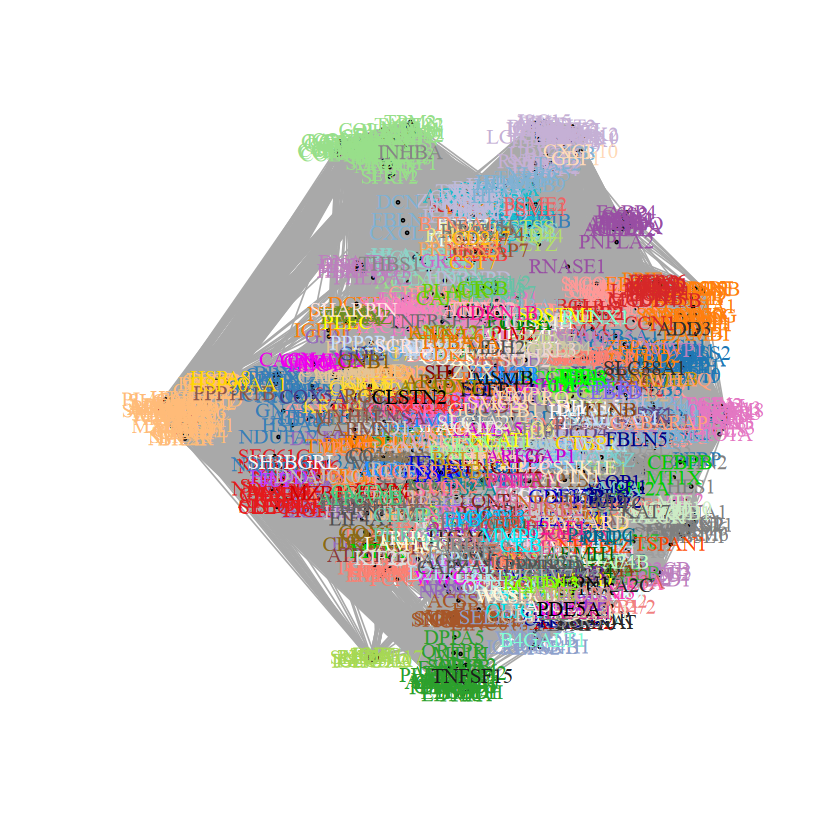

ERROR: Error in pheatmap(res$celltypeinvolvement, col = colorRampPalette(c("white", : could not find function "pheatmap"


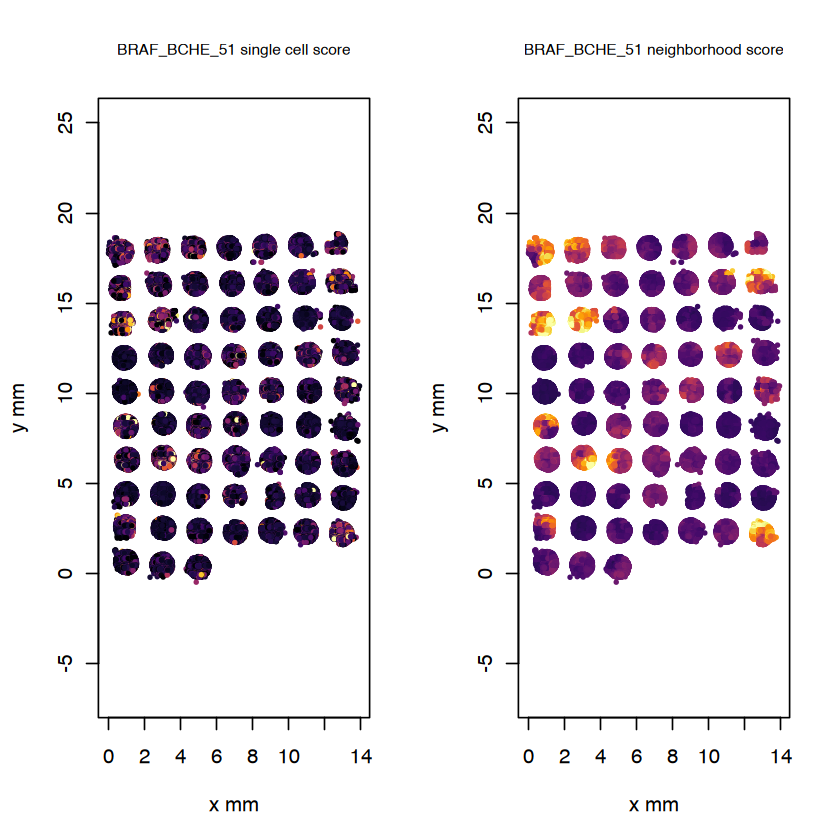

In [17]:
## exploring InSituCor results: 
# You'll want to look for modules that:
# - have interesting genes (look at the module content)
# - involve your cell types of interest (look at the cell type involvement / attribution scores)
# - have interesting spatial patterns (plot their scores in space)

# look at the spatial correlation network:
plotCorrelationNetwork(res$condcor, modules = res$modules, show_gene_names = TRUE, 
                       corthresh = 0.1)

# look at module content:
head(res$modules)

# plot a selected module over space:
par(mfrow = c(1, 2))
# ... at the single cell level:
tempscore <- res$scores_sc[, 1]
plot(xy, asp = 1, pch = 16, cex = 0.5, cex.main = 0.75,
     main = paste0(colnames(res$scores_env)[1], " single cell score"),
     xlab = "x mm", ylab = "y mm",
     col = viridis::viridis_pal(option = "B")(101)[
       1 + pmin(round(100 * (tempscore / quantile(tempscore, 0.995))), 100)])
# ... and at the level of cellular neighborhoods:
tempscore <- res$scores_env[, 1]
plot(xy, asp = 1, pch = 16, cex = 0.5, cex.main = 0.75,
     main = paste0(colnames(res$scores_env)[1], " neighborhood score"),
     xlab = "x mm", ylab = "y mm",
     col = viridis::viridis_pal(option = "B")(101)[
       1 + pmin(round(100 * (tempscore / quantile(tempscore, 0.995))), 100)])

# look at the involvement of each cell type in each module:
pheatmap(res$celltypeinvolvement, col = colorRampPalette(c("white", "darkblue"))(100),
         main = "Contribution of cell types to module scores")

# zoom in on the cell type involvement for a single module:
pheatmap(res$attributionmats[[1]], col = colorRampPalette(c("white", "darkblue"))(100),
         main = "Contribution of cell types to module genes")

In [126]:
set.seed(42)  # For reproducibility

n_cores <- 3
n_genes <- 100

cat("Creating test data...\n")

# Create 3 correlation matrices (100 x 100 each)
test_condcors <- array(NA, 
                       dim = c(n_cores, n_genes, n_genes),
                       dimnames = list(
                         paste0("Core", 1:n_cores),
                         paste0("Gene", 1:n_genes),
                         paste0("Gene", 1:n_genes)
                       ))

# Generate realistic correlation matrices
for (i in 1:n_cores) {
  # Generate random symmetric correlation matrix
  random_mat <- matrix(runif(n_genes * n_genes, -0.8, 0.8), n_genes, n_genes)
  
  # Make symmetric
  random_mat <- (random_mat + t(random_mat)) / 2
  
  # Set diagonal to 0
  diag(random_mat) <- 0
  
  test_condcors[i, , ] <- random_mat
}

Creating test data...


In [127]:
dim(test_condcors)

[1]   3 100 100

In [128]:
build_consensus_network <- function(condcors, 
                                    method = "lowq", 
                                    threshold = 0.2,
                                    min_fraction = NULL) {
  
  n_cores <- dim(condcors)[1]
  n_genes <- dim(condcors)[2]
  
  # Determine quantile from min_fraction
  if (!is.null(min_fraction)) {
    if (min_fraction < 0 || min_fraction > 1) {
      stop("min_fraction must be between 0 and 1")
    }
    quantile <- 1 - min_fraction
    cat("Using min_fraction =", min_fraction, 
        "→ require edge in ≥", ceiling(n_cores * min_fraction), "cores)\n")
  } else {
    min_fraction <- 1
    quantile <- 0
    cat("No min_fraction provided, all cores required.\n")
  }
  
  cat("Building consensus network using method:", method, "\n")
  cat("Threshold:", threshold, "\n")
  
  # Initialize result matrix
  summary_cor <- matrix(0, n_genes, n_genes)
  
  # Determine target rank for lowq method
  if (method == "lowq") {
    target_rank <- ceiling(n_cores * quantile)
    if (target_rank < 1) target_rank <- 1
  }
  
  # Process row by row (memory efficient, still leverages symmetry)
  cat("Processing", n_genes, "rows...\n")
  
  for (row in 1:n_genes) {
    if (row %% 500 == 0) cat("  Row", row, "of", n_genes, "\n")
    
    # Only process upper triangle: columns from row+1 to n_genes
    if (row < n_genes) {
      cols <- (row + 1):n_genes
      n_cols <- length(cols)
      
      # Extract values for this row across all cores: [n_cores, n_cols]
      row_vals <- matrix(NA, nrow = n_cores, ncol = n_cols)
      for (i in 1:n_cores) {
        row_vals[i, ] <- condcors[i, row, cols]
      }
      
      # Compute summary statistic
      if (method == "mean") {
        row_summary <- colMeans(row_vals, na.rm = TRUE)
        
      } else if (method == "maxq") {
        row_summary <- apply(row_vals, 2, max, na.rm = TRUE)
        
      } else if (method == "lowq") {
        row_summary <- apply(row_vals, 2, function(x) {
          sort(x, na.last = TRUE)[target_rank]
        })
      }
      
      # Store in upper triangle
      summary_cor[row, cols] <- row_summary
    }
  }
  
  # Mirror to lower triangle
  summary_cor <- summary_cor + t(summary_cor)
  diag(summary_cor) <- 0
  
  rownames(summary_cor) <- dimnames(condcors)[[2]]
  colnames(summary_cor) <- dimnames(condcors)[[3]]
  
  # Create consensus network
  cat("Creating consensus network...\n")
  consensus <- (summary_cor > threshold) * 1
  keep_genes <- (rowSums(consensus) > 0) & (colSums(consensus) > 0)
  consensus <- consensus[keep_genes, keep_genes]
  
  cat("Consensus network has", nrow(consensus), "genes and", 
      sum(consensus)/2, "edges\n")
  
  return(list(
    adjacency = consensus,
    correlations = summary_cor[keep_genes, keep_genes]
  ))
}

In [153]:
method <- "lowq"
threshold <- 0.2
min_fraction <- 2/3

In [154]:
quantile <- 1 - min_fraction
print(quantile)
cat("Building consensus network using method:", method, "\n")
cat("Threshold:", threshold, ", Quantile:", round(quantile, 3), "\n")

if (method == "lowq") {
summary_cor <- apply(test_condcors, 2:3, quantile, probs = quantile, na.rm = TRUE)
} else if (method == "maxq") {
summary_cor <- apply(test_condcors, 2:3, max, na.rm = TRUE)
} else if (method == "mean") {
summary_cor <- apply(test_condcors, 2:3, mean, na.rm = TRUE)
}

diag(summary_cor) <- 0
consensus <- (summary_cor > threshold) * 1
keep_genes <- (rowSums(consensus) > 0) & (colSums(consensus) > 0)
consensus <- consensus[keep_genes, keep_genes]

cat("Consensus network has", nrow(consensus), "genes and", 
    sum(consensus)/2, "edges\n")

[1] 0.3333333
Building consensus network using method: lowq 
Threshold: 0.2 , Quantile: 0.333 
Consensus network has 100 genes and 377 edges


In [155]:
n_genes <- dim(test_condcors)[2]

quantile <- 1 - min_fraction
print(quantile)
cat("Building consensus network using method:", method, "\n")
cat("Threshold:", threshold, ", Quantile:", round(quantile, 3), "\n")

# Initialize result matrix
summary_cor <- matrix(0, n_genes, n_genes)
  
# Determine target rank for lowq method
if (method == "lowq") {
  target_rank <- ceiling(n_cores * quantile)
  if (target_rank < 1) target_rank <- 1
  cat("Target rank:", target_rank, "\n")
}
  
# Process row by row (memory efficient, still leverages symmetry)
cat("Processing", n_genes, "rows...\n")
  
for (row in 1:n_genes) {
  if (row %% 500 == 0) cat("  Row", row, "of", n_genes, "\n")
  
  # Only process upper triangle: columns from row+1 to n_genes
  if (row < n_genes) {
    cols <- (row + 1):n_genes
    n_cols <- length(cols)
    
    # Extract values for this row across all cores: [n_cores, n_cols]
    row_vals <- matrix(NA, nrow = n_cores, ncol = n_cols)
    for (i in 1:n_cores) {
      row_vals[i, ] <- test_condcors[i, row, cols]
    }
    
    # Compute summary statistic
    if (method == "mean") {
      row_summary <- colMeans(row_vals, na.rm = TRUE)
      
    } else if (method == "maxq") {
      row_summary <- apply(row_vals, 2, max, na.rm = TRUE)
      
    } else if (method == "lowq") {
      row_summary <- apply(row_vals, 2, quantile, probs = quantile, na.rm = TRUE)
    }
    
    # Store in upper triangle
    summary_cor[row, cols] <- row_summary
  }
}

# Mirror to lower triangle
summary_cor <- summary_cor + t(summary_cor)
diag(summary_cor) <- 0

rownames(summary_cor) <- dimnames(test_condcors)[[2]]
colnames(summary_cor) <- dimnames(test_condcors)[[3]]

# Create consensus network
cat("Creating consensus network...\n")
consensus <- (summary_cor > threshold) * 1
keep_genes <- (rowSums(consensus) > 0) & (colSums(consensus) > 0)
consensus <- consensus[keep_genes, keep_genes]

cat("Consensus network has", nrow(consensus), "genes and", 
    sum(consensus)/2, "edges\n")

[1] 0.3333333
Building consensus network using method: lowq 
Threshold: 0.2 , Quantile: 0.333 
Target rank: 1 
Processing 100 rows...
Creating consensus network...
Consensus network has 100 genes and 377 edges
